##**Importing Libraries**

In [1]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

##**Dataset**

**Dataset Preparation**

In [3]:
class LensDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        self.labels = []
        self.class_map = {'no': 0, 'sphere': 1, 'vort': 2}
        self.classes = list(self.class_map.keys())  # Store class names

        for class_name, label in self.class_map.items():
            class_folder = os.path.join(root_dir, class_name)
            if not os.path.exists(class_folder):
                print(f"Warning: {class_folder} not found.")
                continue
            for file in os.listdir(class_folder):
                if file.endswith(".npy"):
                    file_path = os.path.join(class_folder, file)
                    array = np.load(file_path)
                    tensor = torch.tensor(array, dtype=torch.float32)
                    if tensor.ndim == 2:  # If the image is grayscale, add channel dimension
                        tensor = tensor.unsqueeze(0)
                    self.data.append(tensor)
                    self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

**Defining Dataset Paths**

In [4]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/dataset/train"
val_dir = "/content/drive/MyDrive/dataset/val"


**Data Augmentation**

In [5]:
transform = transforms.Compose([
    transforms.ToPILImage(),                  # Convert tensor (from .npy) to PIL image
    transforms.RandomHorizontalFlip(p=0.5),   # 50% chance to flip horizontally
    transforms.RandomRotation(degrees=15),    # Random rotation between -15 and 15 degrees
    transforms.ToTensor(),                    # Convert back to tensor
    transforms.Normalize((0.5,), (0.5,))        # Normalize: update the mean and std if needed
])

In [6]:
# Load datasets
val_dataset = LensDataset(train_dir, transform=transform)
full_dataset = LensDataset(val_dir, transform=transform)

In [7]:
from collections import Counter

# If your custom dataset stores labels in a list (e.g., final_val_dataset.labels)
label_counts = Counter(val_dataset.labels)
print("Final Validation Label Distribution:", label_counts)

Final Validation Label Distribution: Counter({0: 10000, 1: 10000, 2: 10000})


**Splitting the Train dataset**

In [8]:
# 90:10 split of train data
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [9]:
# Print dataset sizes
print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 6750, Test samples: 750, Val samples: 30000


In [10]:
print(f"Classes: {full_dataset.classes}")

Classes: ['no', 'sphere', 'vort']


In [11]:
print(f"Classes: {val_dataset.classes}")

Classes: ['no', 'sphere', 'vort']


##**Modelling**

**Defining CNN model**

In [21]:
class ImprovedCNNModel(nn.Module):
    def __init__(self):
        super(ImprovedCNNModel, self).__init__()
        # Convolution Block 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Convolution Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Convolution Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # Pooling and dropout
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        # After three pooling operations, the spatial dimensions reduce from 150x150 to approximately 18x18.
        self.fc1 = nn.Linear(128 * 18 * 18, 256)
        self.fc2 = nn.Linear(256, 3)  # 3 output classes

    def forward(self, x):
        # Block 1: Conv -> BatchNorm -> ReLU -> Pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Block 2: Conv -> BatchNorm -> ReLU -> Pool
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Block 3: Conv -> BatchNorm -> ReLU -> Pool
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        # Flatten the tensor
        x = x.view(x.size(0), -1)
        # Fully connected layers with dropout
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

**Preparing the Model**

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedCNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

**Training the Model**

In [23]:
# Function to reset model weights between folds
def reset_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        m.reset_parameters()

# Assume train_dataset is your full training dataset (e.g. loaded from your "val" folder)
# and that it has an attribute 'labels' which is a list of labels.
#full_dataset.labels = [0, 1, 2]
full_dataset_for_cv = ConcatDataset([train_dataset, test_dataset]) # Using train_dataset and test_dataset for CV
# Get all labels by iterating through the ConcatDataset
all_labels = []
for i in range(len(full_dataset_for_cv)):  # Assuming full_dataset_for_cv is your ConcatDataset
    _, label = full_dataset_for_cv[i]
    all_labels.append(label)
all_labels = np.array(all_labels)

# Compute class weights to address imbalance (if any)
classes = np.unique(all_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=all_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class Weights:", class_weights)

# Define the loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Set training parameters
num_epochs = 40
batch_size = 32
learning_rate = 0.001
num_folds = 5

# Prepare cross-validation: Stratified K-Fold ensures each fold has a similar distribution of classes.
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

fold_results = {}

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
    print(f"\n--- Fold {fold+1}/{num_folds} ---")
    # Create subsets for this fold
    fold_train_dataset = Subset(full_dataset, train_idx)
    fold_val_dataset   = Subset(full_dataset, val_idx)

    fold_train_loader = DataLoader(fold_train_dataset, batch_size=batch_size, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_dataset, batch_size=batch_size, shuffle=False)

    # Reinitialize model weights for this fold
    model.apply(reset_weights)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in fold_train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(fold_train_loader)
        print(f"Fold {fold+1} Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    # Evaluate the model on the fold's validation set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in fold_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")
    fold_results[fold] = accuracy

# Optionally, print the average cross-validation accuracy
avg_accuracy = np.mean(list(fold_results.values()))
print(f"\nAverage Cross-Validation Accuracy: {avg_accuracy:.4f}")

Class Weights: tensor([1., 1., 1.], device='cuda:0')

--- Fold 1/5 ---
Fold 1 Epoch 1/40, Loss: 1.8140
Fold 1 Epoch 2/40, Loss: 1.0989
Fold 1 Epoch 3/40, Loss: 1.0987
Fold 1 Epoch 4/40, Loss: 1.0987
Fold 1 Epoch 5/40, Loss: 1.0986
Fold 1 Epoch 6/40, Loss: 1.0986
Fold 1 Epoch 7/40, Loss: 1.0986
Fold 1 Epoch 8/40, Loss: 1.0986
Fold 1 Epoch 9/40, Loss: 1.0986
Fold 1 Epoch 10/40, Loss: 1.0986
Fold 1 Epoch 11/40, Loss: 1.0986
Fold 1 Epoch 12/40, Loss: 1.0986
Fold 1 Epoch 13/40, Loss: 1.0986
Fold 1 Epoch 14/40, Loss: 1.0986
Fold 1 Epoch 15/40, Loss: 1.0986
Fold 1 Epoch 16/40, Loss: 1.0986
Fold 1 Epoch 17/40, Loss: 1.0986
Fold 1 Epoch 18/40, Loss: 1.0986
Fold 1 Epoch 19/40, Loss: 1.0986
Fold 1 Epoch 20/40, Loss: 1.0986
Fold 1 Epoch 21/40, Loss: 1.0986
Fold 1 Epoch 22/40, Loss: 1.0986
Fold 1 Epoch 23/40, Loss: 1.0986
Fold 1 Epoch 24/40, Loss: 1.0986
Fold 1 Epoch 25/40, Loss: 1.0986
Fold 1 Epoch 26/40, Loss: 1.0986
Fold 1 Epoch 27/40, Loss: 1.0986
Fold 1 Epoch 28/40, Loss: 1.0986
Fold 1 Epoch 2

**Evaluating the model**

In [25]:
def evaluate(loader, model, device, classes):
    model.eval()
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    auc_scores = []
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        # Create binary labels for one-vs-all AUC computation
        binary_labels = (all_labels == i).astype(int)
        # Ensure there are both positive and negative samples for this class
        if len(np.unique(binary_labels)) < 2:
            print(f"Warning: Class '{classes[i]}' does not have both positive and negative samples; skipping AUC.")
            auc_value = float('nan')
        else:
            auc_value = roc_auc_score(binary_labels, all_probs[:, i])
        auc_scores.append(auc_value)
        fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={auc_value:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    return auc_scores

Evaluating on Test Set (from the 'val' folder split):


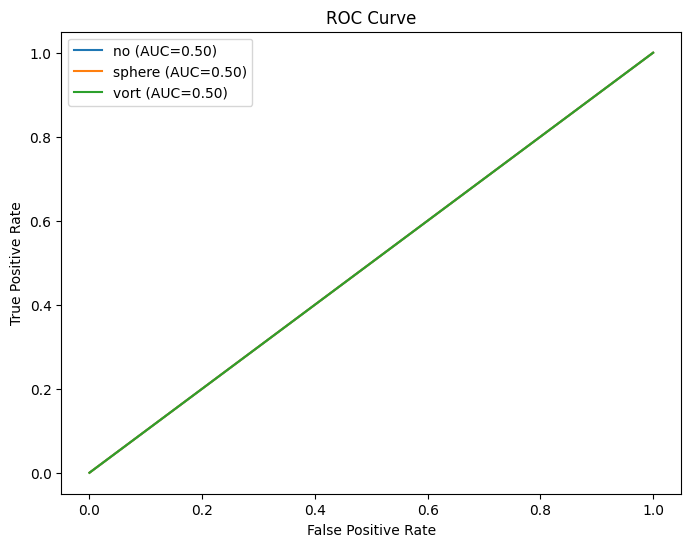

Test AUC Scores: [np.float64(0.5), np.float64(0.5), np.float64(0.5)]


In [26]:
print("Evaluating on Test Set (from the 'val' folder split):")
test_auc_scores = evaluate(test_loader, model, device, full_dataset.classes)
print("Test AUC Scores:", test_auc_scores)

In [27]:
from collections import Counter

# If your custom dataset stores labels in a list (e.g., final_val_dataset.labels)
label_counts = Counter(full_dataset.labels)
print("Final Validation Label Distribution:", label_counts)

Final Validation Label Distribution: Counter({0: 2500, 1: 2500, 2: 2500})


Evaluating on Final Validation Set (from the 'train' folder):


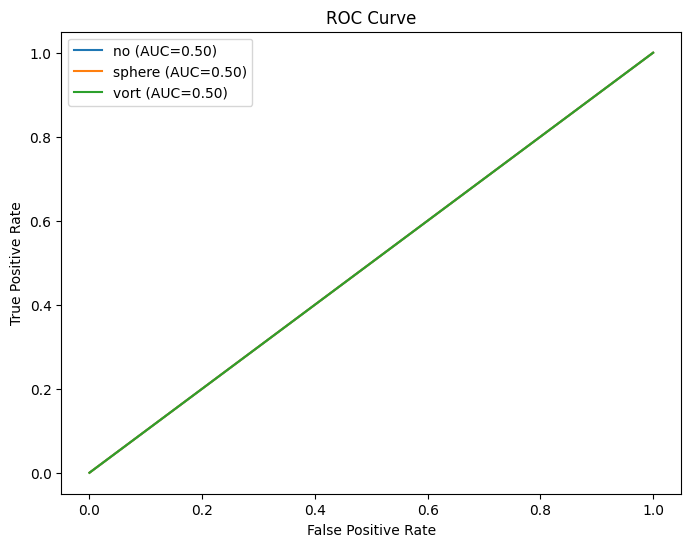

Validation AUC Scores: [np.float64(0.5), np.float64(0.5), np.float64(0.5)]


In [28]:
print("Evaluating on Final Validation Set (from the 'train' folder):")
val_auc_scores = evaluate(val_loader, model, device, val_dataset.classes)
print("Validation AUC Scores:", val_auc_scores)

**Saving the model**

In [29]:
# Define the path where the model weights will be saved
model_path = "/content/cnn_weights1"

# Save only the model's state_dict (recommended)
torch.save(model.state_dict(), model_path)

print(f"Model weights saved to {model_path}")

Model weights saved to /content/cnn_weights1
